In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt


In [ ]:
SEED = 42
np.random.seed(SEED)

# Load training set (80%)
train_df = pd.read_csv("train_set_80_percent.csv")
train_df = train_df.drop(columns=["id", "rank", "player","hard_hit_95mph+"])
train_df = train_df.dropna()

# Load test set (20%)
test_df = pd.read_csv("test_set_20_percent.csv")
test_df = test_df.drop(columns=["id", "rank", "player","hard_hit_95mph+"])
test_df = test_df.dropna()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (1577, 16)
Test shape: (397, 16)


In [ ]:
target = "hard_hit_percentage"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]


In [ ]:
#best model from training w/ optimal hyperparameter
ridge = Pipeline([
    ("scale", StandardScaler()),
    ("model", Ridge(alpha=1, max_iter=10000, random_state=SEED))
])
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)


In [ ]:
#test metrics
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print("Final Test-Set Results (Ridge)")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test R² : {test_r2:.4f}")

Final Test-Set Results (Ridge)
Test MSE: 3.6844
Test R² : 0.9354


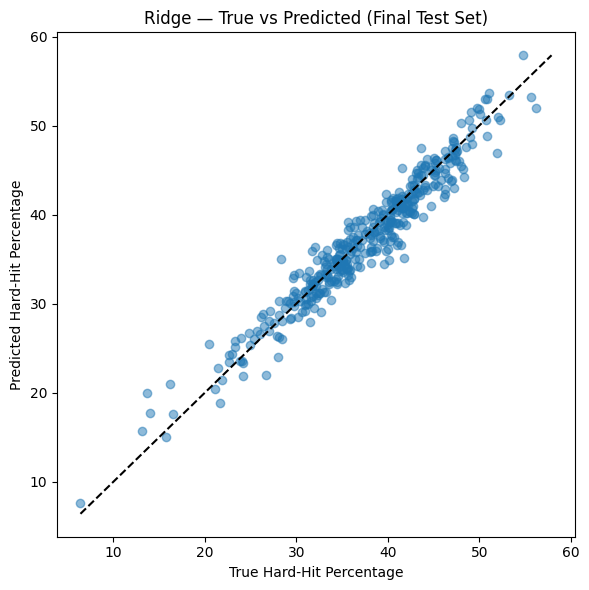

In [ ]:
#plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("True Hard-Hit Percentage")
plt.ylabel("Predicted Hard-Hit Percentage")
plt.title("Ridge — True vs Predicted (Final Test Set)")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--")

plt.tight_layout()
plt.show()